# Trabajo final

## Introducción y descripción del problema

A través del presente notebook se va a desarrollar el proyecto final de la asignatura **Ciencia de Datos y Aprendizaje Automático**.

El caso de uso planteado se basa en el **diseño** y **desarrollo** de un **modelo predictivo** capaz de identificar cuándo un cliente podría abandonar los servicios de una entidad financiera a partir un conjunto de datos recopilados.

Para abordar este caso de uso, se disponen de los siguientes **ficheros**:

- Un conjunto de datos de **entrenamiento** de **8.000** instancias.

- Un conjunto de datos de **prueba** de **2.000** instancias.
    
- Un formato de **muestra** para el envío resultados a la plataforma Kaggle.

Para la realización de la práctica, se va a utilizar la metodología **CRISP-DM** para abordar la conversión del Dato al Conocimiento.

## Necesidad de Negocio

La fuga de clientes de las instituciones financieras es uno de los mayores desafíos, ya que la adquisición de nuevos clientes suele resultar mucho más costoso que retener a uno existente. Este fenómeno no solo afecta los ingresos directos del banco, sino también su estabilidad a largo plazo, al perder la confianza y la base de clientes.

La capacidad de **predecir** con antelación qué clientes tienen mayor probabilidad de abandonar la
entidad se convierte en una **herramienta estratégica** esencial permitiendo focalizar esfuerzos, optimizar recursos en campañas de retención y, en definitiva, mejorar la relación con los clientes y la sostenibilidad del negocio.

Para el cumplimiento de este objetivo de negocio, se parte de un conjunto de datos sobre los clientes de la entidad financiera. 

# Comprensión y procesado de datos

Continuando con la metodología CRISP-M, pasamos a una siguiente **fase de comprensión de los datos**, el cual tiene el objetivo de familiarizarse con los datos, identificando problemas de calidad y viendo datos de valor. Todo ello acorde con el objetivo de negocio que se persigue.

En esta fase, se va a realizar un **extenso análisis descriptivo** del conjunto de datos de entrenamiento que nos pueda servir como base de cualquier decisión a tomar para la generación de los consiguientes modelos de clasificación.

 ## Análisis exploratorio

 A lo largo de la sección, se van a ir comentando las observaciones del análisis.

In [1]:
from pathlib import Path
import os

import pandas as pd

RANDOM_STATE = 22
N_SPLIT = 5

IMG_DIR = Path("img")
IMG_DIR.mkdir(parents=True, exist_ok=True)


# Cargamos los dataset
trainData = pd.read_csv("train.csv", sep=",")
testData = pd.read_csv("test.csv", sep=",")

# Dimensiones
print("Dimensiones del dataset de entrenamiento (filas/columnas):", trainData.shape)

# Información general
trainData.info()

# Duplicidad en la variable del cliente
print("\n -- Duplicado el mismo cliente: ", trainData['CustomerId'].duplicated().sum())

Dimensiones del dataset de entrenamiento (filas/columnas): (8000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       8000 non-null   int64  
 1   Surname          7591 non-null   object 
 2   CreditScore      6359 non-null   float64
 3   Geography        8000 non-null   object 
 4   Gender           8000 non-null   object 
 5   Age              8000 non-null   int64  
 6   Tenure           8000 non-null   int64  
 7   Balance          6385 non-null   float64
 8   NumOfProducts    7024 non-null   float64
 9   HasCrCard        7625 non-null   float64
 10  IsActiveMember   8000 non-null   int64  
 11  EstimatedSalary  7168 non-null   float64
 12  Exited           8000 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 812.6+ KB

 -- Duplicado el mismo cliente:  0


### Observación 1

- La variable _CustomerId_ no presenta duplicados en el conjunto de entrenamiento. Además, no aporta información predictiva y podría introducir ruido, por lo que será **anulada**.

- La variable _Surname_ tampoco aporta información predictiva, solamente ruido, por lo que será **anulada**.

- Pese a que se disponen de 13 columnas, hay **10** variables predictoras y **una** variable objetivo (Exited).
    - De las 10 variables predictoras, 8 son numéricas (4 son discretas, 2 son binarias y 2 continuas) y 2 variables categóricas.

In [2]:
# Comprobación de valores faltantes
print("\n -- Valores faltantes en el conjunto de entrenamiento -- \n", trainData.isnull().sum())

# Calculo del porcentaje de valores faltantes por columna
trainMissingDataPorcentage = (trainData.isnull().mean() * 100).sort_values(ascending = False)
print("\n -- Porcentaje de valores faltantes en el conjunto de entrenamiento -- \n", trainMissingDataPorcentage)

# Comprobación de instancias con valores perdidos
print("\n -- Instancias con valores perdidos frente al total: ", str(trainData.dropna().shape[0]) + "/" + str(trainData.shape[0]))


 -- Valores faltantes en el conjunto de entrenamiento -- 
 CustomerId            0
Surname             409
CreditScore        1641
Geography             0
Gender                0
Age                   0
Tenure                0
Balance            1615
NumOfProducts       976
HasCrCard           375
IsActiveMember        0
EstimatedSalary     832
Exited                0
dtype: int64

 -- Porcentaje de valores faltantes en el conjunto de entrenamiento -- 
 CreditScore        20.5125
Balance            20.1875
NumOfProducts      12.2000
EstimatedSalary    10.4000
Surname             5.1125
HasCrCard           4.6875
CustomerId          0.0000
Geography           0.0000
Gender              0.0000
Age                 0.0000
Tenure              0.0000
IsActiveMember      0.0000
Exited              0.0000
dtype: float64

 -- Instancias con valores perdidos frente al total:  4464/8000


### Observación 2
- El conjunto de datos contiene 5.848 valores faltantes, y un **55,8%** (4464) de las instancias presentan algún valor faltante.
- La **falta de valores** no es un problema "residual", sino que afecta a más de la mitad de las filas. Esto podría afectar a variables predictoras con mayor asociación con la variable objetivo.

In [3]:
# Estadísticas descriptivas
print("\n -- Descripción de los datos de entrenamiento -- \n", trainData.describe())


 -- Descripción de los datos de entrenamiento -- 
          CustomerId  CreditScore          Age       Tenure        Balance  \
count  8.000000e+03  6359.000000  8000.000000  8000.000000    6385.000000   
mean   1.569119e+07   661.235257    38.935000     5.013875   76929.669179   
std    7.187227e+04    95.876126    10.381389     2.888810   62292.133487   
min    1.556570e+07   350.000000    18.000000     0.000000       0.000000   
25%    1.562896e+07   595.000000    32.000000     3.000000       0.000000   
50%    1.569112e+07   664.000000    37.000000     5.000000   98009.130000   
75%    1.575373e+07   729.000000    44.000000     8.000000  127660.460000   
max    1.581569e+07   850.000000    92.000000    10.000000  250898.090000   

       NumOfProducts    HasCrCard  IsActiveMember  EstimatedSalary      Exited  
count    7024.000000  7625.000000     8000.000000      7168.000000  8000.00000  
mean        1.539721     0.706623        0.513500    100057.165753     0.20375  
std        

### Observación 4

- Las variables presentan **diferentes escalas**. Por ejemplo, la variable _CreditScore_ oscila entre 350 y 850, mientras las variables sobre el salario (_Balance_ y _EstimatedSalary_) en miles y, la edad (_Age_) en decenas. Este hecho requerirá una **estandarización** de los datos.

### Siguientes pasos

A continuación, proseguiré el análisis exploratorio con una mayor profundidad.

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Balanceo de la variable clase
print("\n -- Balanceo de la variable de clase (Exited) --")

numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary']
conteo = trainData['Exited'].value_counts()
porcentaje = trainData['Exited'].value_counts(normalize = True) * 100 # proporción en lugar de conteo
for clase in conteo.index:
    print(f"Clase {clase}: {conteo[clase]} instancias ({porcentaje[clase]:.2f}%)")


 -- Balanceo de la variable de clase (Exited) --
Clase 0: 6370 instancias (79.62%)
Clase 1: 1630 instancias (20.38%)


### Observación 6

- La variable objetivo presenta un **desbalanceo (80% frente a 20%)**. Este hecho afectará a métricas como _accurancy_, así como a algoritmos que tienden a favorecer a la clase mayoritaria. Además, durante el entrenamiento, existe el **riesgo** de sobreajuste en la clase mayoritaria y subajuste de la clase minoritaria.

In [5]:
# Correlación con la variable clase
print("\n -- Correlación con la variable de clase --")
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary']
corr_target = trainData[numeric_cols + ['Exited']].corr(numeric_only = True)['Exited']
corr_target = corr_target.drop('Exited').sort_values(key = lambda s: s.abs(), ascending = False)
print(corr_target)


 -- Correlación con la variable de clase --
Age                0.286788
IsActiveMember    -0.151504
Balance            0.122234
NumOfProducts     -0.081740
CreditScore       -0.023388
Tenure            -0.023380
HasCrCard         -0.012204
EstimatedSalary    0.011856
Name: Exited, dtype: float64


### Observación 7

- En la exploración de **correlaciones** entre los atributos numéricos y la variable a predecir, se encuentran variables con **mayor asociación** con la variable de clase. Concretamente, las variables **_Age_**,  **_isActiveMember_**, **_Balance_** y **_NumOfProducts_**. El resto presentan correlaciones bajas (<= 0,081).

Este hecho nos será relevante para poner el **foco** en estas variables.



 -- Distribución de cada variable con la variable de clase --

 -- Variables discretas --


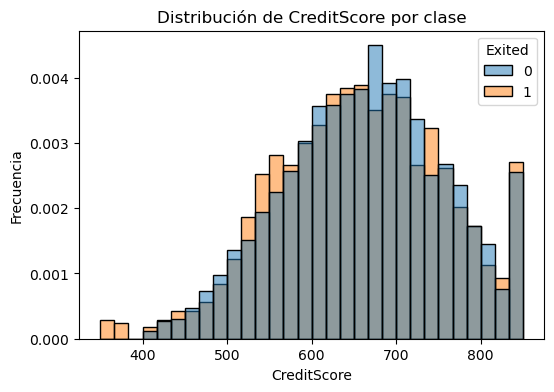

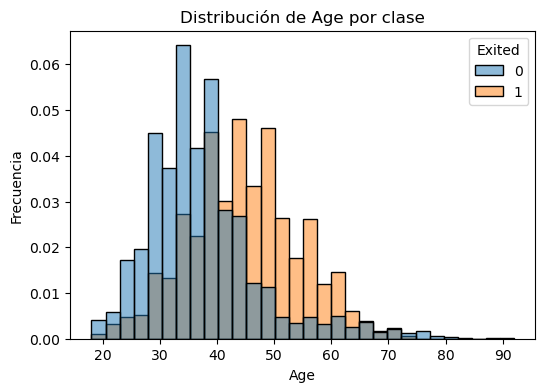

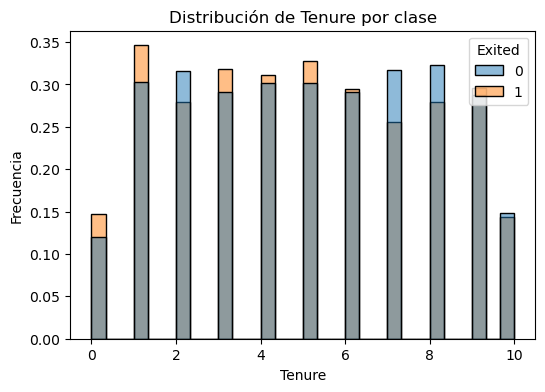

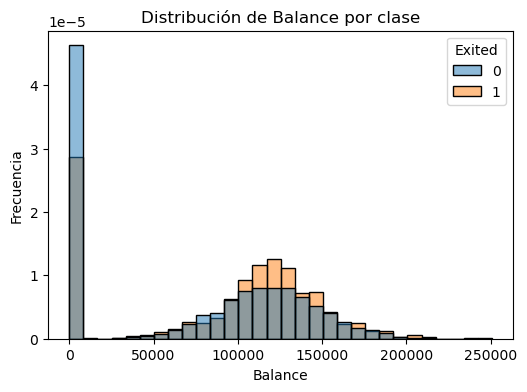

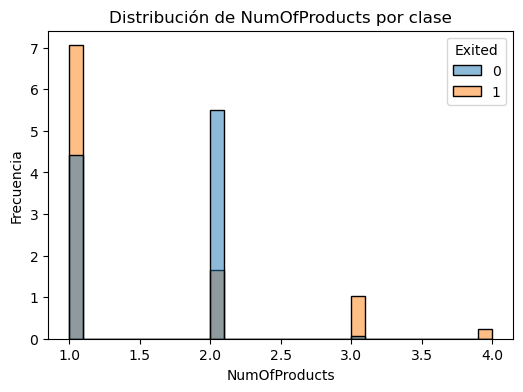

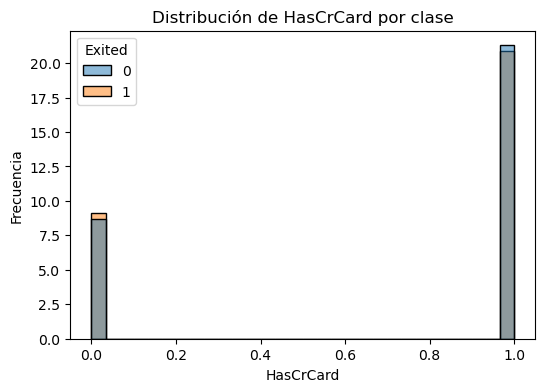

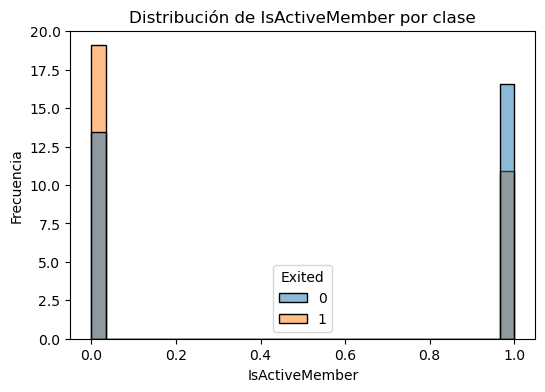

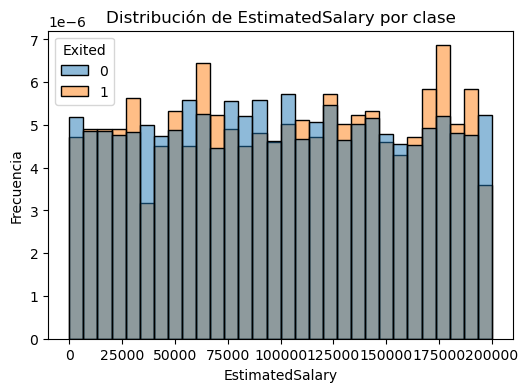


 -- Variables categóricas --


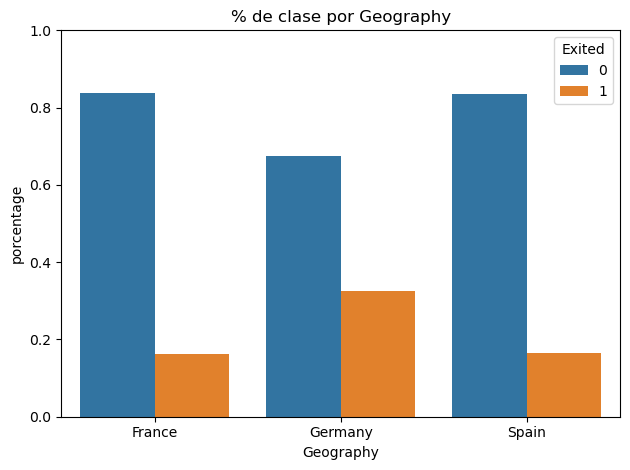

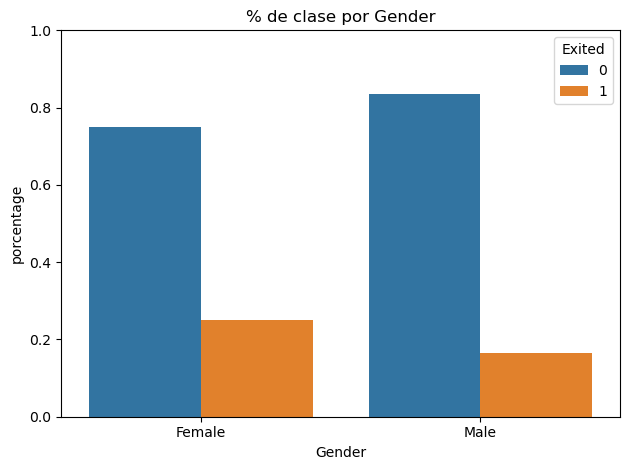

In [6]:
# Distribución de cada variable con la variable clase
print("\n -- Distribución de cada variable con la variable de clase --")

print("\n -- Variables discretas --")
for col in numeric_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(data = trainData, x = col, hue = 'Exited',
                 bins = 30, stat='density', common_norm = False)
    plt.title(f"Distribución de {col} por clase")
    plt.xlabel(f"{col}")
    plt.ylabel('Frecuencia')
    plt.savefig(f"img/distribution-num-{col}.png")
    plt.show()
    
print("\n -- Variables categóricas --")
for col in ['Geography','Gender']:
    # Tabla de proporciones por categoría
    ct = pd.crosstab(trainData[col], trainData['Exited'], normalize = 'index')

    # Pasar a formato largo para seaborn
    tmp = ct.reset_index().melt(id_vars = col, var_name = 'Exited', value_name = 'porcentage')
    
    sns.barplot(data = tmp, x = col, y = 'porcentage', hue = 'Exited')

    plt.title(f"% de clase por {col}")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(f"img/distribution-cat-{col}.png")
    plt.show()

# Preparación de los datos
El objetivo de esta fase es transformar los **datos brutos** en **datos preparados** para ser modelados, con una selección, limpieza, construcción, integración y formato de los datos.

### Decisiones tomadas en base al análisis exploratorio

**1. Eliminación** de las columnas que no aportan valor (__CustomerId__ y __Surname__).

**2. Gestión de los valores faltantes**: el importante número de valores ausentes (55,8%) en total, incluyendo variables clave (_Balance_, por ejemplo), no son ruido, sino que aportan **información** a la clase. Por ello, **crearemos nuevas columnas binarias** bajo la nomenclatura _NA_.

Esto nos permitirá contemplar el patrón "falta del dato" como **señal de comportamiento**.

- Ejemplos:
  - CreditScore_NA → 1 si ese registro no tenía CreditScore; 0 si sí tenía.
  - Balance_NA → 1 si faltaba Balance.
  - Etc.

- Esto nos permitirá que, cuando imputemos con mediana, no perdamos la señal de que faltaba el dato.

**3. Estandarización de variables y gestión de los valores fuera de rango**: corregiremos los valores imposibles marcándolos como _NA_, permitiendo que la imputación lo convierta en un valor faltante. Además, las variables _HasCrCard_ y _IsActiveMember_ las voy a estandarizar al formato _boolean_. Y las variables _NumOfProducts_ y _Tenure_ al formato _int_.
 
**4. Gestión de los valores fuera de rango y no contemplados**: os valores imposibles serán marcados como _NA_, permitiendo que la imputación lo convierta en un valor faltante. Si se encontrara una categoría que no esté contemplada, se califará como desconocida: _Unknown_ (_on-hot_ lo soporta en su configuración). En su conjunto, se definen un conjunto de reglas de Negocio, las cuales, en un contexto real, se podrían adaptar (por ejemplo, existencia de más paises).

**5. Discretización de variables destacadas**
- A partir de la variable numérica _Age_, se va a discretizar por **grupos funcionales** (joven, adulto, senior y mayor) para facilitar la interpretación y capturación de los datos. Desde el punto de vista del negocio, permitiría aplicar, por ejemplo, políticas de retención por tramo de edad.
- A partir de la variable numérica _Balance_, se va a discretizar en función del sueldo para valorar el impacto económico.

**6. Variables y su imputación**: tanto para las variables numéricas como las variables categóricas se ha utilizado el estándar de preparación de datos. Esto es: para las numéricas, imputación mediante la mediana y el escalar estándar; para las categóricas, imputación mediante la moda y adecuación a valores binarios.

**7. Más atributos descriptivos**
- De cara a aumentar el rendimiento de los modelos, he incluido diferentes combinaciones de variables.

In [7]:
# importación  del Pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Listas base
numerical_features = trainData.select_dtypes(include=['number']).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['CustomerId', 'Exited']]
categorical_features = trainData.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [col for col in categorical_features if col not in ['Surname']]

# Columnas que anularemos
drop_cols = ['CustomerId','Surname']

X_train = trainData.drop('Exited', axis = 1)
y_train = trainData['Exited']

X_test  = testData.copy()

def business_rules(df: pd.DataFrame) -> pd.DataFrame:
    #0. trabajar con una copia
    out = df.copy()

    #1. eliminación columnas de ruido
    out = out.drop(columns=[c for c in drop_cols if c in out.columns])

    # 2. Creación de nuevas columnas _NA
    na_cols = ["Balance", "EstimatedSalary", "NumOfProducts", "CreditScore"]
    for col in na_cols:
        out[col + "_NA"] = out[col].isna().astype(int)

    # 3. Valores fuera de rango
    out.loc[(out["Age"] < 18) | (out["Age"] > 110), "Age"] = np.nan
    out.loc[(out["Tenure"] < 0), "Tenure"] = np.nan
    out.loc[(out["CreditScore"] < 300) | (out["CreditScore"] > 900), "CreditScore"] = np.nan
    out["HasCrCard"] = out["HasCrCard"].where(out["HasCrCard"].isin([0, 1, 0.0, 1.0]))
    out["HasCrCard"] = out["HasCrCard"].astype("boolean")
    out["IsActiveMember"] = out["IsActiveMember"].where(out["IsActiveMember"].isin([0, 1, 0.0, 1.0]))
    out["IsActiveMember"] = out["IsActiveMember"].astype("boolean")
    out.loc[out["Balance"] < 0, "Balance"] = np.nan
    out.loc[out["EstimatedSalary"] < 0, "EstimatedSalary"] = np.nan

    
    out["Age_safe"] = out["Age"].replace(0, np.nan)
    out["NumProducts_safe"] = out["NumOfProducts"].replace(0, np.nan)
    out["EstimatedSalary_safe"] = out["EstimatedSalary"].replace(0, np.nan)

    # 4. Consistencia categórica
    valid_geo = ["France", "Spain", "Germany"]
    out["Geography"] = out["Geography"].where(out["Geography"].isin(valid_geo), "Unknown")

    valid_gender = ["Male", "Female"]
    out["Gender"] = out["Gender"].where(out["Gender"].isin(valid_gender), "Unknown")

    # 5. Discretización por edad y salario    
    bins_age = [18, 30, 45, 65, np.inf]
    labels_age = ["Young", "Adult", "Senior", "Old"]
    
    out["AgeGroup"] = pd.cut(out["Age_safe"],
                             bins=bins_age,
                             labels=labels_age,
                             right=True, # intervalos abiertos por la izquierda
                             include_lowest=True)
    
    out["HighBalance"] = (out["Balance"] > 100000).astype(int)
    out["Salary_bin"] = pd.qcut(df["EstimatedSalary"], q=4, duplicates="drop")

    # 6. nuevos atributos por fusión
    out["Age_x_Active"] = out["Age_safe"] * out["IsActiveMember"].astype("Int64")
    out["Age_x_Balance"] = out["Balance"] * out["Age_safe"]
    out["Activity_x_Balance"] = out["IsActiveMember"] * out["Balance"]
    out["Salary_/_Age"] = out["EstimatedSalary_safe"] / (out["Age_safe"])
    out["Balance_/_Age"] = out["Balance"] / out["Age_safe"]
    out["Products_x_Active"] = out["NumProducts_safe"] * out["IsActiveMember"].astype(int)
    out["Age_x_NumOfProducts"] = out["Age_safe"] * out["NumProducts_safe"]
    out["Age_x_Tenure"] = out["Age_safe"] * out["Tenure"]
    out["CreditScore_/_Age"] = out["CreditScore"] / out["Age_safe"]
    out["GeoGender"] = (out["Geography"].astype(str) + "_" + out["Gender"].astype(str))
    out["HasCrCard_x_Age"] = out["HasCrCard"] * out["Age_safe"]
    out["Age_x_CreditScore"] = out["Age_safe"] * out["CreditScore"]
    
    out["Germany_x_Age"] = (out["Geography"] == "Germany").astype(int) * out["Age_safe"]
    out["Germany_x_Balance"] = (out["Geography"] == "Germany").astype(int) * out["Balance"]
    out["Germany_x_CreditScore"] = (out["Geography"] == "Germany").astype(int) * out["CreditScore"]

    out["Age_x_Salary"] = out["Age_safe"] * out["EstimatedSalary_safe"]
    out["Age_x_Balance_x_Active"] = (
        out["Age_safe"] * out["Balance"] * out["IsActiveMember"].astype(int)
    )
    out.replace([np.inf, -np.inf], np.nan, inplace=True)

    return out

**6. Variables y su imputación**

Tanto para las variables numéricas como las variables categóricas se utilizará el **estándar de preparación de datos**. Esto es: para las numéricas, imputación mediante la mediana y el escalar estándar; para las categóricas, imputación mediante la moda y adecuación a valores binarios. Esta **estrategia** nos permite resolver:
- Cubrir el problema de los valores ausentes, gracias a la imputación mediante la mediana y la moda respectivamente.
- Estandarizar variables con rangos muy amplios, mitigándolo con _StandardScaler_.
- La codificación OneHot nos permite evitar errores si aparecen categorías nuevas.

In [8]:
fe_transformer = FunctionTransformer(business_rules)

In [9]:
from sklearn.impute import KNNImputer

USE_KNN = False  # probar KNNImputer en numéricas

if USE_KNN:
    numerical_transformer = Pipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=7, weights="distance", metric="nan_euclidean")),
        ("scaler" , StandardScaler()) # estandariza la escala
    ])
else:
    numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")), # robusta a outliers
        ("scaler" , StandardScaler()) # estandariza la escala
    ])


numerical_transformer_knn = Pipeline(steps=[
    ("imputer", KNNImputer(
        n_neighbors=7,          # valor mediano
        weights="distance",     # pondera vecinos cercanos
        metric="nan_euclidean"  # estándar para datos ausentes
    )),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # variables binarias
])

In [10]:
from sklearn.compose import ColumnTransformer

# Tras experimentacion, no aporta valor
drop_cols_origin = ['Gender', 'HasCrCard', 'Geography', 'Tenure', 'IsActiveMember']
categorical_features = [col for col in categorical_features if col not in drop_cols_origin]
numerical_features = [col for col in numerical_features if col not in drop_cols_origin]

# Tras experimentacion, reduzco columnas
ENGINEERED_NUM = [
    #"EstimatedSalary_NA","CreditScore_NA", "Balance_NA", "NumOfProducts_NA",
    "Age_x_Active",
    "Age_x_Balance",
    #"Age_x_CreditScore",
    #"Age_x_Salary",
    #"Products_x_Active",
    "Age_x_Tenure",
    "Age_x_NumOfProducts",
    #"Age_x_Balance_x_Active",
    "CreditScore_/_Age",
    #"HasCrCard_x_Age",
    #"Activity_x_Balance",
    "Germany_x_Age"
    #,"Germany_x_Balance"
]

# Tras experimentacion, reduzco columnas
ENGINEERED_CAT = [
    #"AgeGroup"
    #,"HighBalance"
    #"Salary_bin"
    #,"GeoGender"
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features + ENGINEERED_NUM),
        ('cat', categorical_transformer, categorical_features + ENGINEERED_CAT)
    ]
    ,remainder='drop' # lo no incluido, se borra
)

In [11]:
print(numerical_features + ENGINEERED_NUM)
print(categorical_features + ENGINEERED_CAT)

['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Age_x_Active', 'Age_x_Balance', 'Age_x_Tenure', 'Age_x_NumOfProducts', 'CreditScore_/_Age', 'Germany_x_Age']
[]


### Uso de pipelines

El uso de **pipelines** en scikit‑learn permite **encapsular** todas las fases del preprocesamiento (imputación, escalado, codificación One‑Hot, discretización y reglas de negocio) evitando fugas de información (data leakage).

Esta **estrategia** nos permite asegurar que las métricas sean más robustas y representen fielmente el rendimiento esperado del modelo en producción.

## Modelado

En esta fase, se van a entrenar diferentes modelos supervisados de clasificación binaria:

1. **Regresión Logística**.
2. **Random Forest**, por su capacidad para capturar relaciones no lineales y manejar desbalanceo mediante _class\_weight_.
3. **Gradient Boosting**, por su capacidad para optimizar errores residuales y mejorar el rendimiento en problemas tabulares.

4. **Modelos avanzados**: LightGBM, CatBoost, XGBoost.

Todos los modelos se van a integrar en un **pipeline unificado**. Esto garantiza reproducibilidad, aislando fugas de datos (data leakage) y manteniendo consistencia entre entrenamiento y predicción.

In [12]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# ======================= #
# Modelos
# - Básicos: Regresión logística, clasificación mediante árboles de decisión y boosting de gradiente 
# - Avanzados: LightGBM, CatBoost, XGBoost
# ======================= #
models = {
    "LogisticRegression": LogisticRegression(
        class_weight = "balanced",
        max_iter=150 # evitar que no logre converger al incluir nuevos atributos
    ), # No favorecer la clase mayoritaria
    "RandomForest": RandomForestClassifier(
        random_state = RANDOM_STATE,
        class_weight="balanced_subsample", # Corregir sesgo por clase
         n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state = RANDOM_STATE),
    "LGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        force_col_wise=True,     # evita warnings de validación de feature names
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        random_seed=RANDOM_STATE,
        verbose=0
    ),
    "XGB": XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss', # evitamos warnings
         n_jobs=-1
    )
}

# Pipelines
pipelines = {
    name: Pipeline(steps=[
        ("fe", fe_transformer), # reglas de negocio propias
        ("prep", preprocessor), # imputación + one hot + escalado
        ("clf", model)
    ])
    for name, model in models.items()
}

# Evaluación
Para la evaluación de los modelos, he utilizado **validación cruzada estratificada**, ya que la variable objetivo se encuentra **desbalanceada** (80 vs 20), y este enfoque nos mantiene la misma proporción de clases que en el conjunto original.

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance
import numpy as np

# Validación cruzada estratificada con N_SPLIT
cv = StratifiedKFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)

preds = {} # predicciones en la evaluación
oof_rows = [] # probabilidades para posterior dibujo de curvas P-R
dict_relevances = {} # Diccionario para guardar las importancias finales de cada modelo

for name, pipe in pipelines.items():

    #Obtención de las probabilidades OOF (Out Of Fold)
    #Si no hay proba, usa decision_function y reescala
    try:
        oof_proba = cross_val_predict(
            pipe, X_train, y_train,
            cv=cv, method="predict_proba", n_jobs=-1
        )[:, 1]
    except:
        oof_dec = cross_val_predict(
            pipe, X_train, y_train,
            cv=cv, method="decision_function", n_jobs=-1
        )
        # min-max a [0,1] para poder crear la PR-curve correctamente
        smin, smax = oof_dec.min(), oof_dec.max()
        oof_proba = (oof_dec - smin) / (smax - smin + 1e-9)

    # Guardamos los valores para futuro plot
    y_true = y_train.values if hasattr(y_train, 'values') else np.array(y_train)

    # calculo F1
    preds[name] = cross_validate(pipe, X_train, y_train,
                            cv=cv,
                            scoring={'f1': 'f1'},
                            return_estimator=True, # devuelve los modelos entrenados
                            n_jobs=-1
                           )

    # cálculo de Permutation Importance promediado entre Folds
    fold_importances = []
    
    # Iteramos sobre cada modelo entrenado en cada fold
    for i, trained_pipe in enumerate(preds[name]['estimator']):
        # Calculamos permutation importance usando los mismos datos
        r = permutation_importance(
            trained_pipe, X_train, y_train,
            n_repeats=3,      # Veces que se baraja cada columna
            random_state=42,
            n_jobs=-1
        )
        fold_importances.append(r.importances_mean)
    
    # Promediamos los resultados de todos los folds
    dict_relevances[name] = np.mean(fold_importances, axis=0)
    
    # Guardamos una fila por observación
    oof_rows.extend({"model": name, "y_true": int(yt), "y_score": float(ys)} for yt, ys in zip(y_true, oof_proba))

# Tabla comparativa
rows = []
for name, scores in preds.items():
    f1_mean = scores['test_f1'].mean()
    f1_std  = scores['test_f1'].std()
    rows.append({'Modelo': name, 'F1_mean': f1_mean, 'F1_std': f1_std})
table_f1 = pd.DataFrame(rows).sort_values('F1_mean', ascending=False).reset_index(drop=True)

# Mostrar tabla
print(table_f1)

C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


               Modelo   F1_mean    F1_std
0    GradientBoosting  0.567461  0.017909
1                LGBM  0.559373  0.012599
2            CatBoost  0.556486  0.007480
3                 XGB  0.540564  0.011168
4        RandomForest  0.522469  0.012690
5  LogisticRegression  0.489602  0.013862


In [14]:
# extraigo el preprocesador de uno de los modelos ya entrenados
first_model_name = list(preds.keys())[0]
example_pipe = preds[first_model_name]['estimator'][0]

# Extraemos los nombres de las columnas finales
feature_names = example_pipe.named_steps['prep'].get_feature_names_out()

# Transformamos X_train a su estado final
X_train_transformed = example_pipe.named_steps['fe'].transform(X_train)
X_train_transformed = example_pipe.named_steps['prep'].transform(X_train_transformed)

# calculo Permutation Importance sobre los datos transformados
for name, model_data in preds.items():
    fold_importances = []
    
    for trained_pipe in model_data['estimator']:
        # extraigo solo el classifier final
        classifier = trained_pipe.named_steps['clf']
        
        # Calculamos importancia usando los datos transformados
        r = permutation_importance(
            classifier, X_train_transformed, y_train,
            n_repeats=3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        fold_importances.append(r.importances_mean)
    
    dict_relevances[name] = np.mean(fold_importances, axis=0)

df_imp = pd.DataFrame(dict_relevances, index=feature_names)

with open("variables_relevances.txt", "w") as f:
    for modelo_name, val in df_imp.items():
        f.write(f"=== MODELO: {modelo_name} ===\n")
        
        # creo una serie para ordenar los valores con los nombres de las columnas
        ranking = pd.Series(val, index=feature_names).sort_values(ascending=False)
        
        for col, val in ranking.items():
            f.write(f"{col}: {val:.6f}\n")
        
        f.write("\n") # Espacio entre modelos

print("Archivo 'variables_relevances.txt' generado con éxito.")

C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\loren\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Archivo 'variables_relevances.txt' generado con éxito.


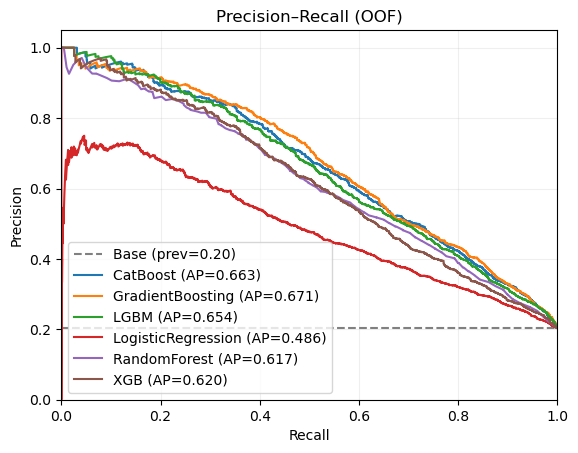

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import pandas as pd

oof_f = pd.DataFrame(oof_rows)

# Línea base: prevalencia de la clase positiva
base = (oof_f['y_true'] == 1).mean()

plt.figure()
plt.hlines(base, 0, 1, colors='gray', linestyles='--', label=f'Base (prev={base:.2f})')

# Curva PR por modelo
for m, g in oof_f.groupby('model'):
    p, r, _ = precision_recall_curve(g['y_true'], g['y_score'])
    ap = average_precision_score(g['y_true'], g['y_score'])
    plt.plot(r, p, label=f'{m} (AP={ap:.3f})')

plt.title('Precision–Recall (OOF)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)
plt.savefig(f"img/curva-PR.png")
plt.show()

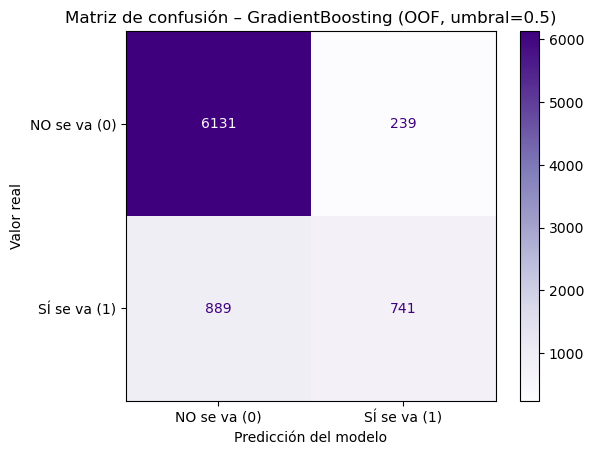

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# mejor modelo
best_model = table_f1.loc[0, "Modelo"]

# obtengo OOF del mejor modelo
oof_best = oof_f[oof_f["model"] == best_model].copy()

y_true = oof_best['y_true'].to_numpy()
y_scr  = oof_best['y_score'].to_numpy()

# 4) Baseline
thr   = 0.5
y_pred = (y_scr >= thr).astype(int)

# 5) Matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=["NO se va (0)", "SÍ se va (1)"])
disp.plot(values_format="d", cmap="Purples")
plt.title(f"Matriz de confusión – {best_model} (OOF, umbral={thr})")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.savefig(f"img/confusion-matrix.png")
plt.show()

Los valores muestran que:

- TP (True Positives): clientes que sí se marchan, y el modelo los detecta.
- FN (False Negatives): clientes que se marchan, y el modelo no detecta.
- FP (False Positives): clientes que no se marchan, pero el modelo dice que sí.
- TN (True Negatives): clientes que no se marchan, y el modelo acierta.

Una vez evaluado los modelos utilizando validación cruzada, eligiré el **mejor modelo** y reentrenaré con **todo** el set de entrenamiento, de cara a que el modelo aproveche todos los datos para aprender el patrón y evitar cualquier pérdida de información.

In [20]:

# Elección del mejor modelo y reentrenamiento con TODO el set de entrenamiento
best_model = table_f1.loc[0, 'Modelo']
print(f"\n -- Mejor modelo: {best_model} --")
best_pipe = pipelines[best_model]
best_pipe.fit(X_train, y_train)
    
# Predecir con el mejor modelo y con el conjunto de test
y_pred = best_pipe.predict(X_test)

submission = pd.DataFrame({
    'CustomerId': testData['CustomerId'].astype(int),
    'Exited': y_pred.astype(int)
})

submission.to_csv("submission.csv", index=False) # Guardarlo como CSV


 -- Mejor modelo: GradientBoosting --


El fichero final ha sido generado siguiendo las normas establecidas para su remisión a través de la plataforma _Kaggle_.